# 1. Análise Exploratória (EDA): Características dos Change Points
Esta etapa valida as *features* extraídas dos eventos de rede antes da classificação pelo GMM.

## Parametrização e Contexto
A análise fundamenta-se na identificação de **transições de estado** na rede. Cada registro representa um ponto de mudança (*Change Point*) que delimita a fronteira estatística entre dois regimes operacionais distintos.

In [12]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configurações de Aparência ---
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# --- Parâmetros do Estudo ---
SCENARIO = "NDT"
METHOD = "vwcd_w20_fn2"
REF_METRIC = "rtt_down"
THRESHOLD = 0.95

# --- Caminho do Arquivo de Features ---
base_path = os.path.join("features", SCENARIO)
if METHOD.startswith("vwcd"):
    file_name = f"features_{METHOD}_{REF_METRIC}_{THRESHOLD}.csv"
else:
    file_name = f"features_{METHOD}_{REF_METRIC}.csv"

full_path = os.path.join(base_path, file_name)

# --- Carregamento ---
df = pd.read_csv(full_path)
print(f"Dataset carregado com sucesso!")


abs_rel = 'rel'
df['d_rtt_up'] = df[f'd_rtt_up_{abs_rel}'] 
df['d_rtt_down'] = df[f'd_rtt_down_{abs_rel}']
relativa_absoluta = 'Relativa' if abs_rel == 'rel' else 'Absoluta'

Dataset carregado com sucesso!


In [13]:
corte = 10 # ms
# Filtro de corte
df_filtrado = df[
    ((df['d_rtt_down_abs'] > 0) & (df['d_rtt_down_abs'] >= corte)) |
    ((df['d_rtt_down_abs'] < 0) & (df['d_rtt_down_abs'] <= -corte))|
    ((df['d_rtt_up_abs'] > 0) & (df['d_rtt_up_abs'] >= corte)) |
    ((df['d_rtt_up_abs'] < 0) & (df['d_rtt_up_abs'] <= -corte))     
]

limiares = {
    'd_tp_up': 10,
    'd_rtt_down': 10
}
df_filtrado = df_filtrado[~((df_filtrado['d_tp_up'] > limiares['d_tp_up']) | (df_filtrado['d_rtt_down'] > limiares['d_rtt_down']))]

### Caracterização Geral do Dataset

Esta etapa quantifica o volume de dados e a diversidade de dispositivos no período analisado para garantir que a base suporta o uso do GMM.

In [14]:
# Extração da Janela Temporal
df_filtrado['timestamp'] = pd.to_datetime(df_filtrado['timestamp'])
data_inicio = df_filtrado['timestamp'].min().strftime('%m/%Y')
data_fim = df_filtrado['timestamp'].max().strftime('%m/%Y')

# Identificação das entidades únicas no dataset
total_clients = df_filtrado['client'].nunique()
total_servers = df_filtrado['server'].nunique()
total_pairs = df_filtrado.groupby(['client', 'server']).ngroups
total_events = len(df_filtrado)

# Cálculo da densidade de eventos por conexão
avg_cp_per_pair = total_events / total_pairs if total_pairs > 0 else 0

# Exibição do Relatório de Viabilidade
print(f"{'='*50}")
print(f" RELATÓRIO DE CARACTERIZAÇÃO DO CENÁRIO: {SCENARIO}")
print(f"{'='*50}")
print(f"Período de Análise:                 {data_inicio} até {data_fim}")
print(f"Limiar de Detecção:                 {THRESHOLD}")
print(f"Total de Clientes únicos:           {total_clients}")
print(f"Total de Servidores únicos:         {total_servers}")
print(f"Total de Pares Cliente-Servidor:    {total_pairs}")
print(f"Total de Eventos (Change Points):   {total_events}")
print(f"Média de eventos por par:           {avg_cp_per_pair:.2f}")
print(f"{'='*50}")

 RELATÓRIO DE CARACTERIZAÇÃO DO CENÁRIO: NDT
Período de Análise:                 10/2025 até 04/2026
Limiar de Detecção:                 0.95
Total de Clientes únicos:           14
Total de Servidores únicos:         8
Total de Pares Cliente-Servidor:    56
Total de Eventos (Change Points):   185
Média de eventos por par:           3.30


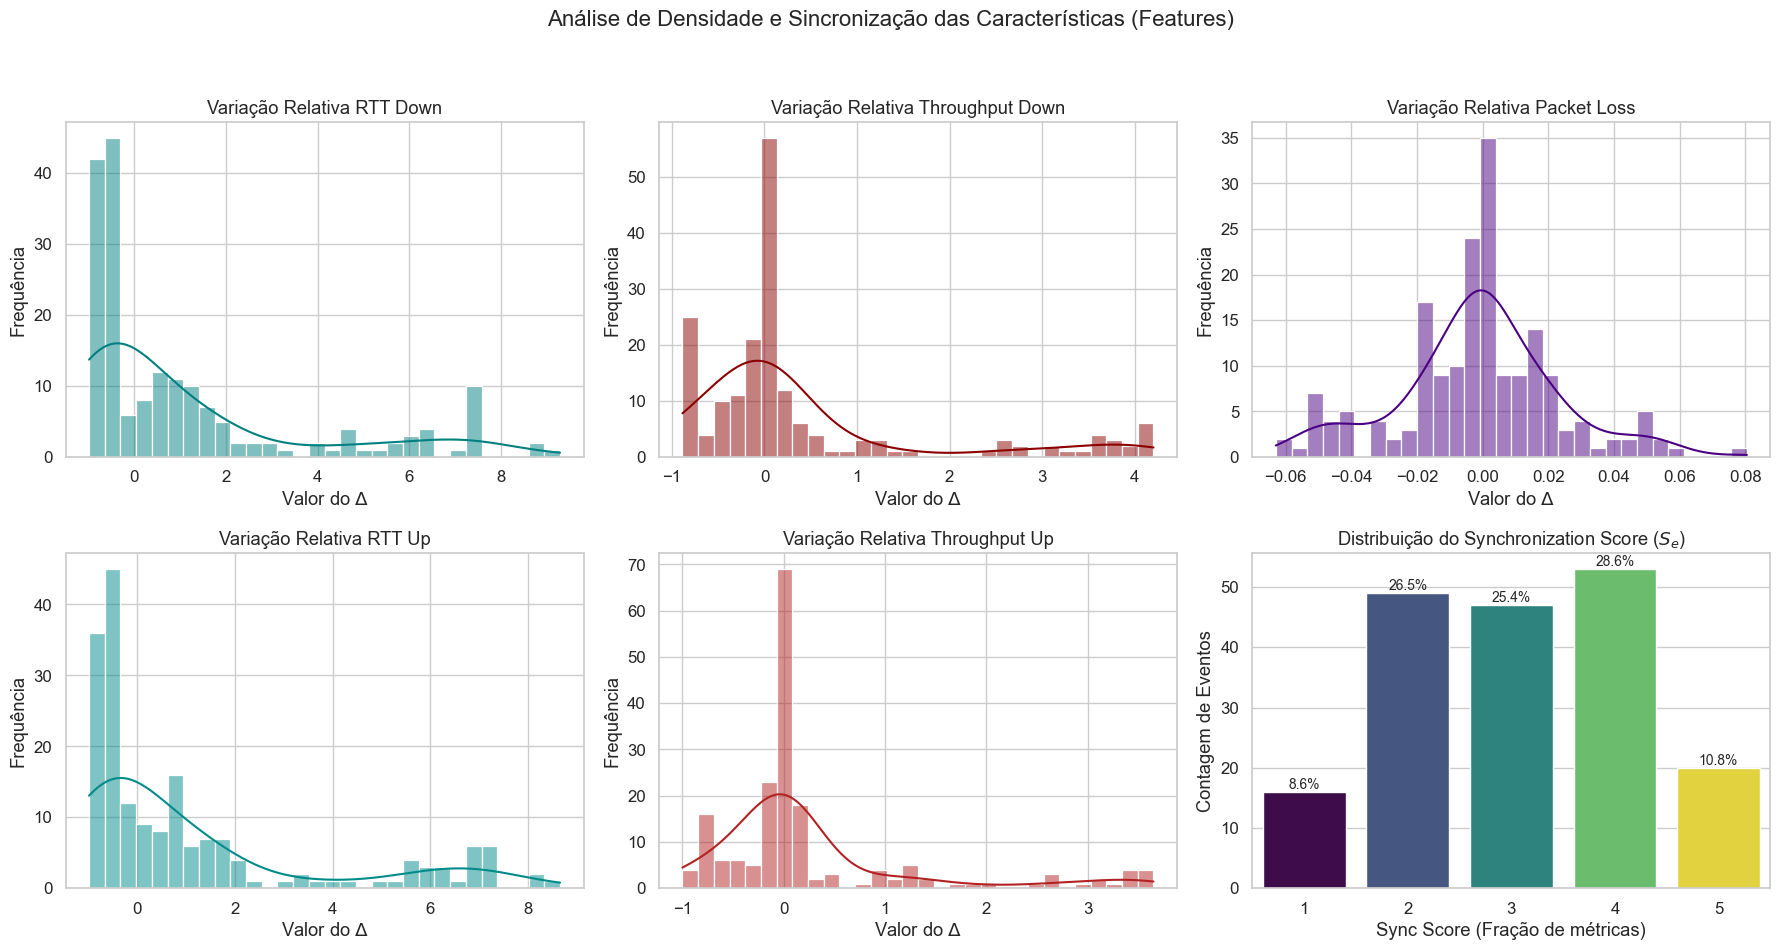

In [15]:
# --- Análise de Sincronização e Distribuições de Variação (Deltas) ---

# Seleção das métricas e configurações de plotagem
metrics_to_plot = [
    ('d_rtt_down', f'Variação {relativa_absoluta} RTT Down', 'teal'),
    ('d_tp_down', f'Variação {relativa_absoluta} Throughput Down', 'darkred'),
    ('d_pl', 'Variação Relativa Packet Loss', 'indigo'),
    ('d_rtt_up', 'Variação Relativa RTT Up', 'darkcyan'),
    ('d_tp_up', 'Variação Relativa Throughput Up', 'firebrick')
]

# Criação da figura 2x3 para consolidar todas as análises
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.suptitle("Análise de Densidade e Sincronização das Características (Features)", fontsize=16)
axes_flat = axes.flatten()

# 1. Plotagem dos Histogramas com KDE para os Deltas (Primeiras 5 posições)
for i, (col, label, color) in enumerate(metrics_to_plot):
    if col in df_filtrado.columns:
        sns.histplot(df_filtrado[col], kde=True, color=color, ax=axes_flat[i], bins=30)
        axes_flat[i].set_title(label)
        axes_flat[i].set_xlabel("Valor do $\\Delta$")
        axes_flat[i].set_ylabel("Frequência")

# 2. Plotagem do Synchronization Score (S_e) na sexta posição
ax_sync = axes_flat[5]
sns.countplot(data=df_filtrado.assign(sync_score=(df_filtrado['sync_score'] * 5).astype(int)), x='sync_score', hue='sync_score', palette='viridis', ax=ax_sync, legend=False)

ax_sync.set_title("Distribuição do Synchronization Score ($S_{e}$)")
ax_sync.set_xlabel("Sync Score (Fração de métricas)")
ax_sync.set_ylabel("Contagem de Eventos")

# Adição de labels de porcentagem sobre as barras do Sync Score
total = len(df_filtrado)
for p in ax_sync.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{100 * height / total:.1f}%'
        ax_sync.annotate(percentage, (p.get_x() + p.get_width() / 2, height), 
                        ha='center', va='bottom', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

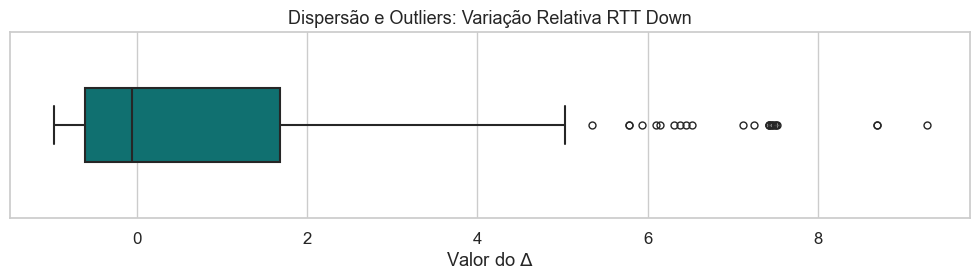

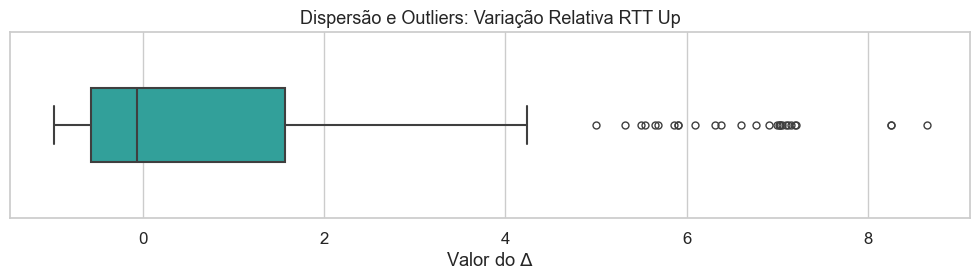

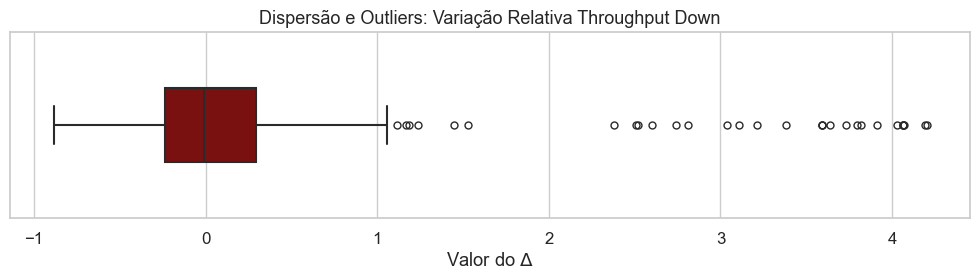

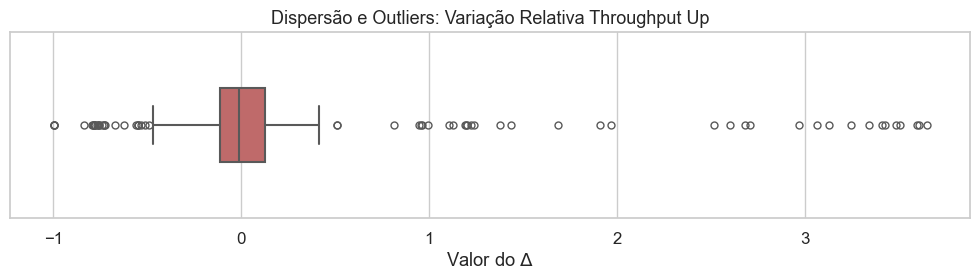

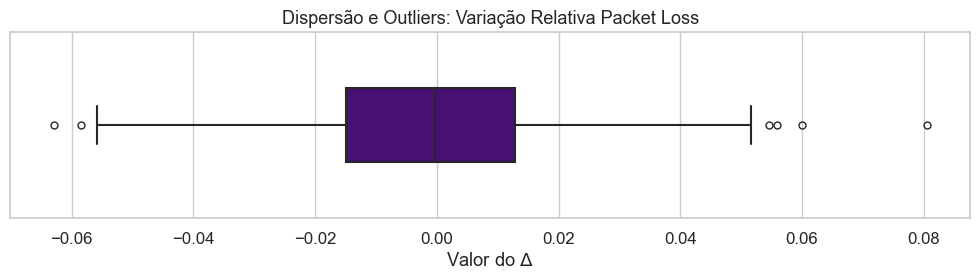

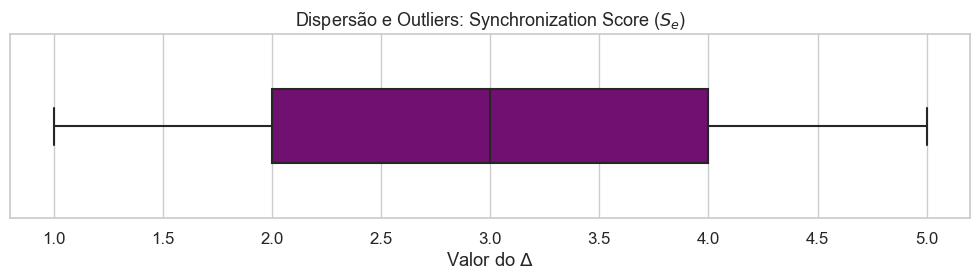

In [16]:
# Configuração das métricas para a plotagem individual dos boxplots
metrics_to_plot_box = [
    ('d_rtt_down', f'Variação {relativa_absoluta} RTT Down', 'teal'),
    ('d_rtt_up', f'Variação {relativa_absoluta} RTT Up', 'lightseagreen'),
    ('d_tp_down', 'Variação Relativa Throughput Down', 'darkred'),
    ('d_tp_up', 'Variação Relativa Throughput Up', 'indianred'),
    ('d_pl', 'Variação Relativa Packet Loss', 'indigo'),
    ('sync_score', 'Synchronization Score ($S_{e}$)', 'purple')
]

# Geração de uma figura independente para cada métrica
for col, label, color in metrics_to_plot_box:
    if col in df_filtrado.columns:
        plt.figure(figsize=(10, 3))
        
        # Criação do boxplot horizontal
        sns.boxplot(
            x=df_filtrado.assign(sync_score=(df_filtrado['sync_score'] * 5).astype(int))[col], 
            color=color, 
            width=0.4, 
            fliersize=5, 
            linewidth=1.5
        )
        
        plt.title(f"Dispersão e Outliers: {label}", fontsize=13)
        plt.xlabel("Valor do $\\Delta$")
        
        # Ajuste de layout para evitar cortes
        plt.tight_layout()
        plt.show()

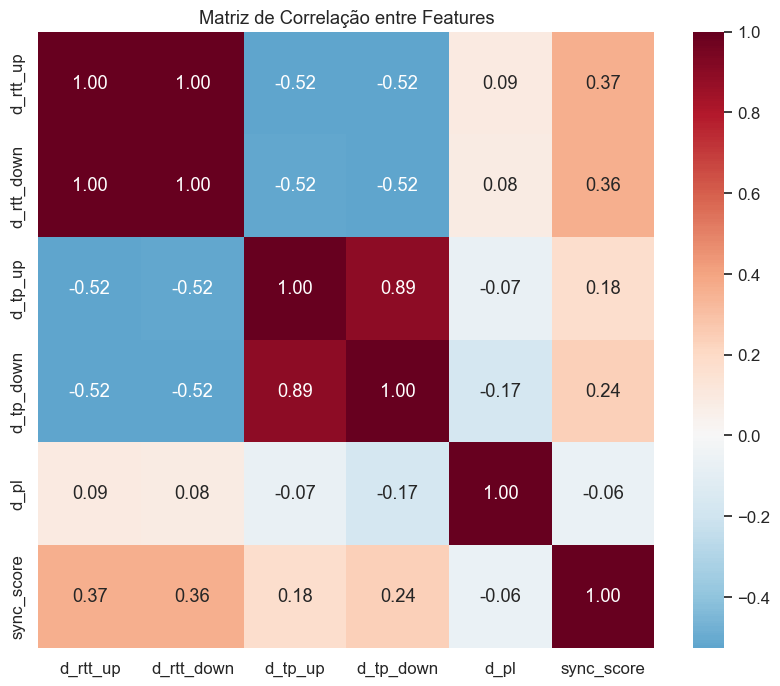

In [17]:
# --- Matriz de Correlação Global ---

plt.figure(figsize=(10, 8))
corr_cols = ['d_rtt_up', 'd_rtt_down', 'd_tp_up', 'd_tp_down', 'd_pl', 'sync_score']
correlation_matrix = df_filtrado[corr_cols].corr()

# Mapa de calor para identificar dependências multivariadas
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", square=True)

plt.title("Matriz de Correlação entre Features")
plt.show()

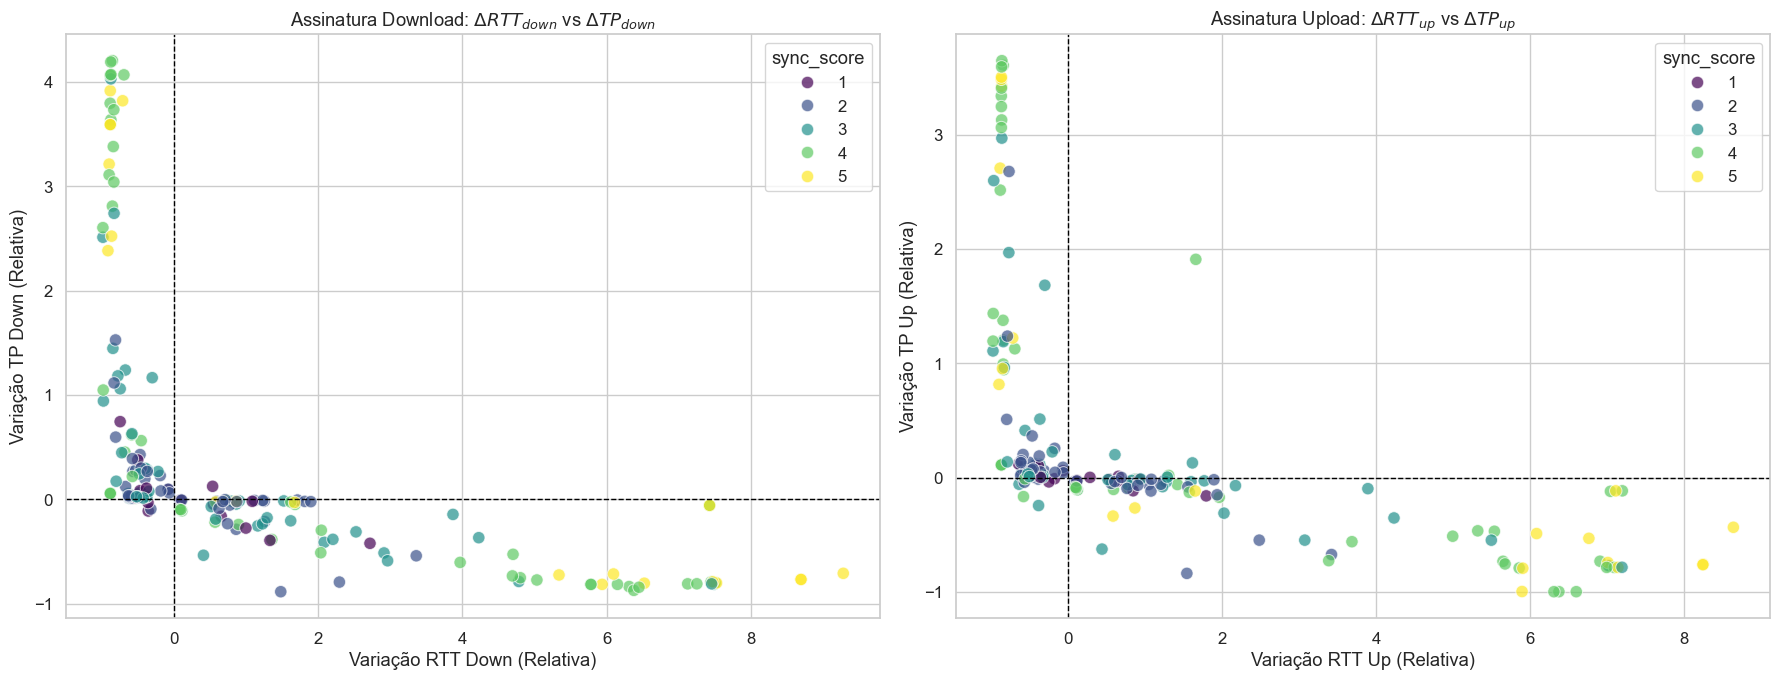

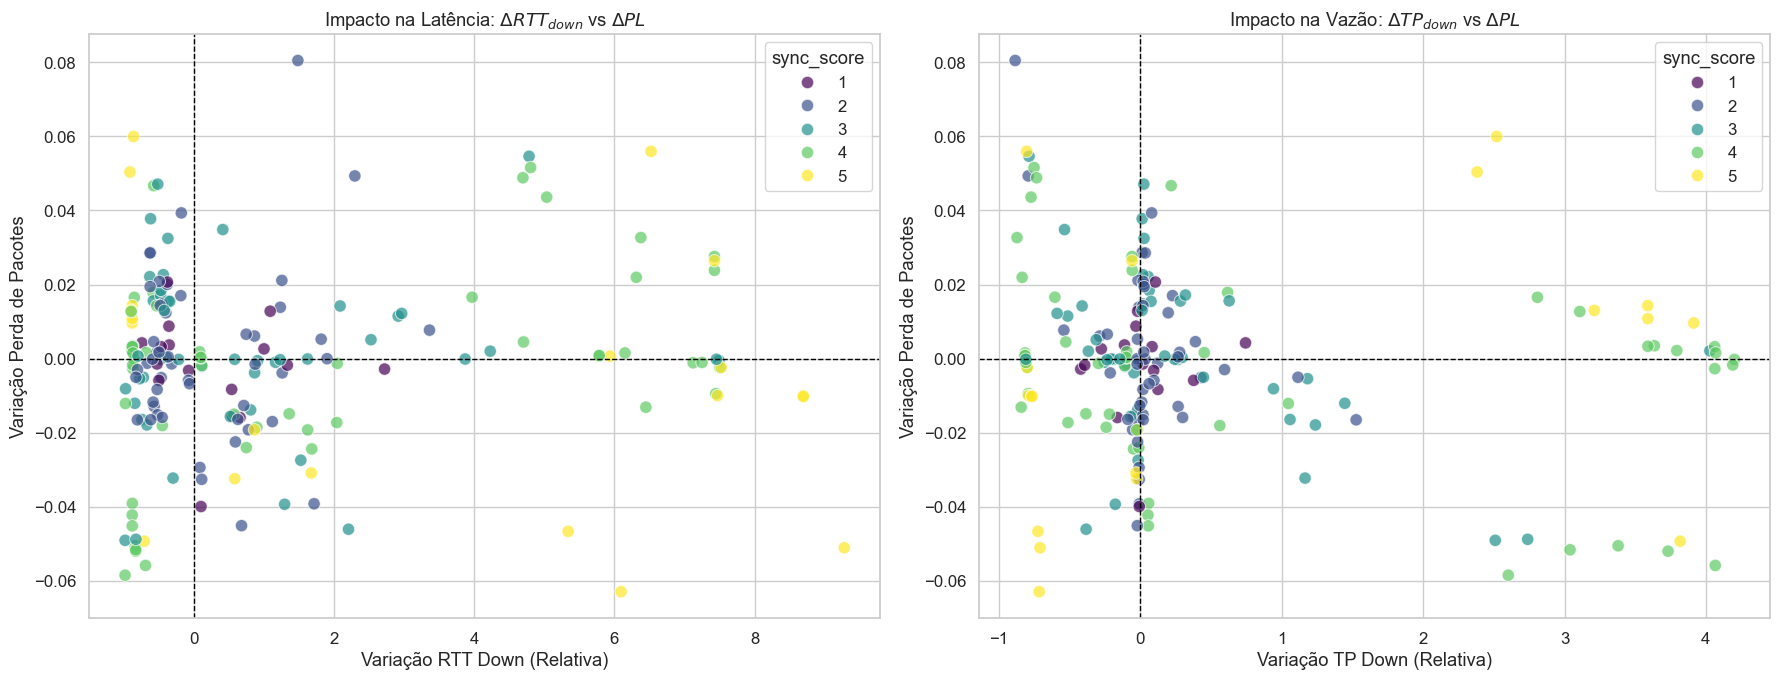

In [18]:
# --- Comparação de Assinaturas: Download vs Upload ---

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Download: RTT vs Throughput
sns.scatterplot(data=df_filtrado.assign(sync_score=(df_filtrado['sync_score'] * 5).astype(int)), x='d_rtt_down', y='d_tp_down', 
                hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[0])
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set_title(r"Assinatura Download: $\Delta RTT_{down}$ vs $\Delta TP_{down}$")
axes[0].set_xlabel(f"Variação RTT Down ({relativa_absoluta})")
axes[0].set_ylabel("Variação TP Down (Relativa)")
# axes[0].set_xlim(-50, 50)
# axes[0].set_ylim(-1, 1)

# 2. Upload: RTT vs Throughput
sns.scatterplot(data=df_filtrado.assign(sync_score=(df_filtrado['sync_score'] * 5).astype(int)), x='d_rtt_up', y='d_tp_up', 
                hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[1])
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_title(r"Assinatura Upload: $\Delta RTT_{up}$ vs $\Delta TP_{up}$")
axes[1].set_xlabel(f"Variação RTT Up ({relativa_absoluta})")
axes[1].set_ylabel("Variação TP Up (Relativa)")

plt.tight_layout()
plt.show()

# --- Análise do Impacto da Perda de Pacotes ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Packet Loss vs RTT Down
sns.scatterplot(data=df_filtrado.assign(sync_score=(df_filtrado['sync_score'] * 5).astype(int)), x='d_rtt_down', y='d_pl', 
                hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[0])
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set_title(r"Impacto na Latência: $\Delta RTT_{down}$ vs $\Delta PL$")
axes[0].set_xlabel(f"Variação RTT Down ({relativa_absoluta})")
axes[0].set_ylabel("Variação Perda de Pacotes")

# 2. Packet Loss vs Throughput Down
sns.scatterplot(data=df_filtrado.assign(sync_score=(df_filtrado['sync_score'] * 5).astype(int)), x='d_tp_down', y='d_pl', 
                hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[1])
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_title(r"Impacto na Vazão: $\Delta TP_{down}$ vs $\Delta PL$")
axes[1].set_xlabel(f"Variação TP Down ({relativa_absoluta})")
axes[1].set_ylabel("Variação Perda de Pacotes")

plt.tight_layout()
plt.show()

In [19]:
# # Definição das métricas e seus respectivos quantis desejados
# config_metricas = {
#     'd_tp_up': 0.99,
#     'd_rtt_down': 0.98
# }

# for feature, quantil in config_metricas.items():
#     # Filtra os dados com base no quantil de corte
#     limiar = df_filtrado[feature].quantile(quantil)
#     features_outliers = df_filtrado[df_filtrado[feature] > limiar]
    
#     print(f"\n--- Análise para a métrica: {feature} (Acima do percentil {quantil*100}%) ---")
#     print(features_outliers[['client', 'server', 'block', 'timestamp', feature]])
    
#     # Gera e exibe o nome dos arquivos únicos correspondentes
#     print("\nArquivos correspondentes aos eventos:")
#     # Usar f-string diretamente no drop_duplicates costuma ser mais rápido e limpo que .apply
#     unique_combos = features_outliers[['client', 'server', 'block']].drop_duplicates()
#     for _, row in unique_combos.iterrows():
#         print(f"{row['client']}_{row['server']}_{row['block']}.csv")

In [20]:
# # Calcula os limiares com base no dicionário de configuração
# limiares = {feature: df_filtrado[feature].quantile(q) for feature, q in config_metricas.items()}
# # Remove os pontos que superam os limites em qualquer uma das métricas configuradas
# df_filtrado_sem_outliers = df_filtrado[~df_filtrado.apply(lambda row: any(row[f] > limiares[f] for f in config_metricas), axis=1)]

# fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# # 1. Download: RTT vs Throughput
# sns.scatterplot(data=df_filtrado_sem_outliers.assign(sync_score=(df_filtrado_sem_outliers['sync_score'] * 5).astype(int)), x='d_rtt_down', y='d_tp_down', 
#                 hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[0])
# axes[0].axhline(0, color='black', lw=1, ls='--')
# axes[0].axvline(0, color='black', lw=1, ls='--')
# axes[0].set_title(r"Assinatura Download: $\Delta RTT_{down}$ vs $\Delta TP_{down}$")
# axes[0].set_xlabel(f"Variação RTT Down ({relativa_absoluta})")
# axes[0].set_ylabel("Variação TP Down (Relativa)")
# # axes[0].set_xlim(-50, 50)
# # axes[0].set_ylim(-1, 1)

# # 2. Upload: RTT vs Throughput
# sns.scatterplot(data=df_filtrado_sem_outliers, x='d_rtt_up', y='d_tp_up', 
#                 hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[1])
# axes[1].axhline(0, color='black', lw=1, ls='--')
# axes[1].axvline(0, color='black', lw=1, ls='--')
# axes[1].set_title(r"Assinatura Upload: $\Delta RTT_{up}$ vs $\Delta TP_{up}$")
# axes[1].set_xlabel(f"Variação RTT Up ({relativa_absoluta})")
# axes[1].set_ylabel("Variação TP Up (Relativa)")

# plt.tight_layout()
# plt.show()

# Clusterização

Tabela de Métricas (Model Selection):
    k      ll     aic      bic    d_ll   d_aic   d_bic
0   2 -425.70  961.41  1138.53    0.00    0.00    0.00
1   3 -277.14  720.29   987.58  148.56 -241.12 -150.95
2   4  -92.36  406.71   764.17  184.79 -313.58 -223.41
3   5  -30.00  338.00   785.63   62.36  -68.71   21.46
4   6   78.64  176.71   714.51  108.64 -161.29  -71.12
5   7  162.23   65.53   693.50   83.59 -111.18  -21.01
6   8  242.16  -38.32   679.82   79.93 -103.85  -13.68
7   9  318.40 -134.80   673.51   76.24  -96.48   -6.31
8  10  350.73 -143.46   755.02   32.33   -8.67   81.50
------------------------------
Melhor K identificado (pelo menor BIC): 9

Estatísticas por Cluster (K=3):
         count  d_rtt_down  d_rtt_up  d_tp_down  d_tp_up   d_pl  sync_score
cluster                                                                    
0           73       3.494     3.374     -0.391   -0.338  0.002       3.123
1           32      -0.710    -0.700      2.285    2.014  0.003       3.625
2 

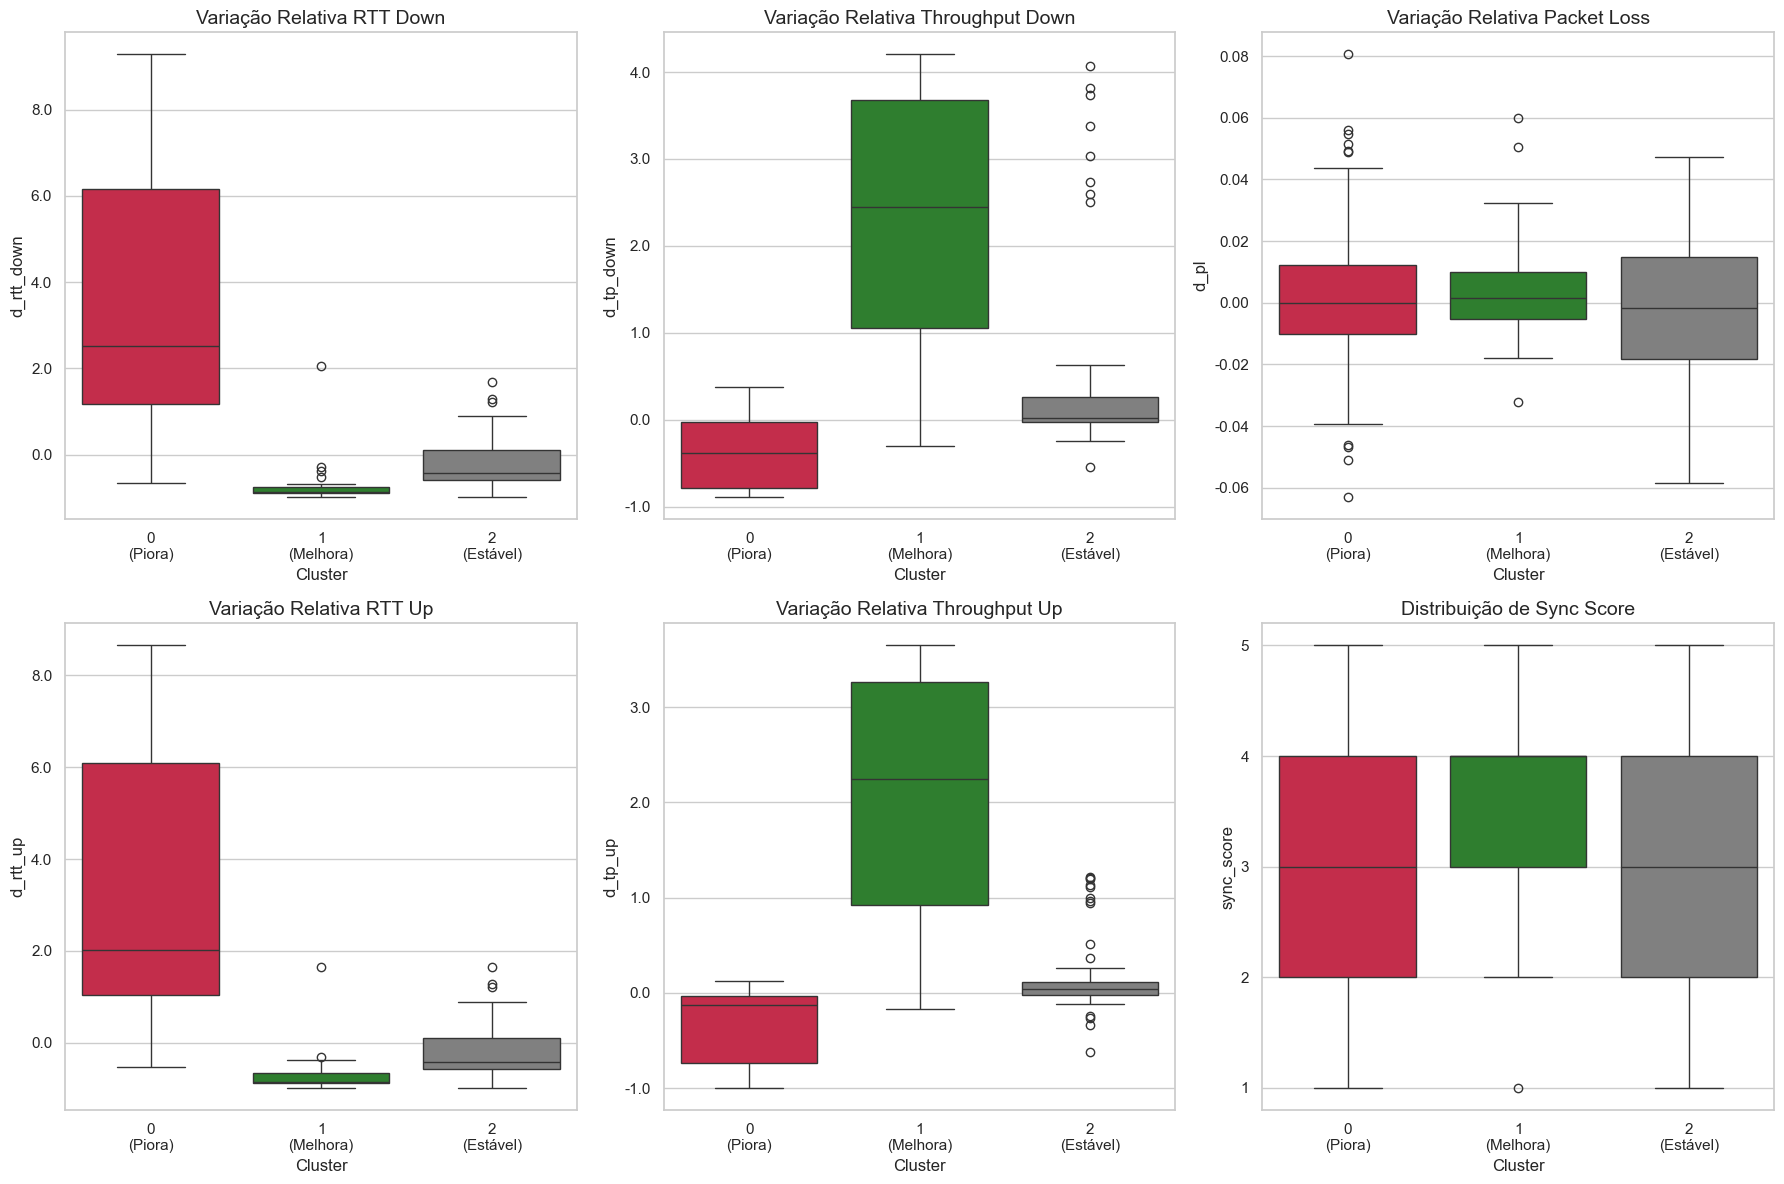

In [21]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# 1. Preparação dos dados
feature_cols = ['d_rtt_down', 'd_tp_down', 'd_rtt_up', 'd_tp_up', 'd_pl', 'sync_score']
X = df_filtrado[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

# 2. Loop para diferentes valores de K
results = []
range_k = range(2, 11)

for k in range_k:
    # ADICIONADO: covariance_type='full' para alinhar com o segundo código
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(X_scaled)
    
    # AJUSTADO: score(X) * len(X) para obter o LL Total em vez da média (lower_bound_)
    ll_total = gmm.score(X_scaled) * len(X_scaled)
    
    results.append({
        'k': k,
        'll': ll_total,
        'aic': gmm.aic(X_scaled), # Adicionado AIC
        'bic': gmm.bic(X_scaled)
    })

# 3. Criar tabela de métricas e calcular variações
df_metrics = pd.DataFrame(results)
df_metrics['d_ll'] = df_metrics['ll'].diff().fillna(0)
df_metrics['d_aic'] = df_metrics['aic'].diff().fillna(0)
df_metrics['d_bic'] = df_metrics['bic'].diff().fillna(0)

print("Tabela de Métricas (Model Selection):")
# Formatação para facilitar a leitura comparativa
print(df_metrics[['k', 'll', 'aic', 'bic', 'd_ll', 'd_aic', 'd_bic']].round(2))
print("-" * 30)

# 4. Encontrar o K ideal
# Para ser consistente com o segundo código, o ideal é olhar o BIC (mínimo valor)
best_k_bic = df_metrics.loc[df_metrics['bic'].idxmin(), 'k']
print(f"Melhor K identificado (pelo menor BIC): {best_k_bic}\n")

K = 3
# 5. Executar o modelo final para o melhor K
gmm_final = GaussianMixture(n_components=int(K), covariance_type='full', random_state=42)
labels = gmm_final.fit_predict(X_scaled)
df_filtrado = df_filtrado.copy()
df_filtrado['cluster'] = labels
if df_filtrado['sync_score'].dtype.kind != 'i':
    df_filtrado['sync_score'] = (df_filtrado['sync_score'] * 5).astype(int)

# 6. Tabela com médias (mantendo a lógica do primeiro código)
cluster_stats = df_filtrado.groupby('cluster').agg(
    count=('cluster', 'size')
).join(df_filtrado.groupby('cluster')[feature_cols].mean())

# Printar com 3 casas decimais para facilitar a leitura
cluster_stats = cluster_stats.round(3)

# ordenar as colunas por rtt, tp e pl para facilitar a comparação entre clusters
cols_order = ['count', 'd_rtt_down', 'd_rtt_up', 'd_tp_down', 'd_tp_up', 'd_pl', 'sync_score']
cluster_stats = cluster_stats[cols_order]
print(f"Estatísticas por Cluster (K={K}):")
print(cluster_stats)

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")

# Definir a ordem das métricas para o grid 2x3
# Download e PL em cima (linha 0), Upload e Sync em baixo (linha 1)
metrics_layout = [
    'd_rtt_down', 'd_tp_down', 'd_pl',   # Topo
    'd_rtt_up', 'd_tp_up', 'sync_score'  # Embaixo
]

metric_info = {
    'd_rtt_down': 'Variação Relativa RTT Down',
    'd_tp_down': 'Variação Relativa Throughput Down',
    'd_pl': 'Variação Relativa Packet Loss',
    'd_rtt_up': 'Variação Relativa RTT Up',
    'd_tp_up': 'Variação Relativa Throughput Up',
    'sync_score': 'Distribuição de Sync Score'
}

# Criar a figura com 6 subplots (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Achatar a matriz de eixos para facilitar o loop

# min d_rtt_down na média é o cluster de recuperação
min_rtt_cluster = cluster_stats['d_rtt_down'].idxmin()
# max d_rtt_down na média é o cluster de congestionamento
max_rtt_cluster = cluster_stats['d_rtt_down'].idxmax()
# o cluster restante é o de mudança de rota
other_cluster = set(cluster_stats.index) - {min_rtt_cluster, max_rtt_cluster}
if K == 3:
    other_cluster = other_cluster.pop()
    cluster_map = {
        min_rtt_cluster: 'Melhora',
        max_rtt_cluster: 'Piora',
        other_cluster: 'Estável'
    }
    cluster_colors = {
        min_rtt_cluster: 'forestgreen',
        max_rtt_cluster: 'crimson',
        other_cluster: 'gray'
    }
    print("\nMapeamento dos Clusters:")
    for k, v in cluster_map.items():
        print(f"Cluster {k}: {v}")

for i, col in enumerate(metrics_layout):
    ax = axes[i]
    
    # Criar o boxplot usando as cores padronizadas no palette
    sns.boxplot(
        x='cluster', 
        y=col, 
        data=df_filtrado, 
        palette=cluster_colors if K==3 else 'Set2',
        hue='cluster', 
        legend=False, 
        ax=ax
    )
    
    # Atualizar os rótulos do eixo X com o mapa de clusters
    ax.set_xticks(ax.get_xticks())
    
    # Inserimos uma quebra de linha '\n' antes do parêntese para os textos não ficarem amontoados
    if K == 3:
        labels = [f"{tick.get_text()}\n({cluster_map.get(int(tick.get_text()), 'Desconhecido')})" 
                for tick in ax.get_xticklabels()]
        ax.set_xticklabels(labels)

    # Forçar ticks inteiros se a variável for o sync_score
    if col == 'sync_score':
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    elif col == 'd_pl': 
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    else:
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # Pega o título do dicionário ou usa um texto padrão se não existir
    title = metric_info.get(col, f'Distribuição de {col}')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Cluster', fontsize=12)
    ax.set_ylabel(col, fontsize=12)

plt.tight_layout()
plt.show()